# Détecter un mot-clé vocal : « éloquence »

Ce notebook raconte, de bout en bout, la construction d'un détecteur de
mot-clé **always-on** : un micro écoute en permanence, et un réseau de
neurones décide plusieurs fois par seconde si le mot « éloquence » vient
d'être prononcé. C'est la première brique d'un assistant vocal : le réveil.

Le fil du notebook suit le projet réel, dans l'ordre où il s'est déroulé :

1. **Les données** — transformer du son brut en nombres qu'un réseau peut lire ;
2. **Un premier modèle** — un réseau convolutif (CNN) entraîné de zéro ;
3. **L'entraînement** — la fonction de coût, le déséquilibre des classes ;
4. **L'évaluation** — et pourquoi il a fallu apprendre à se méfier des métriques ;
5. **Le transfert d'apprentissage** — remplacer le CNN par un extracteur
   pré-entraîné gelé surmonté d'une petite tête ;
6. **Le déploiement** — le modèle servi par une API, avec un registre de
   modèles et des promotions tracées.

Particularité d'un détecteur always-on : **les fausses alarmes comptent plus
que les ratés**. Un mot raté se répète ; un détecteur qui sonne tout seul
plusieurs fois par heure finit débranché. Toute la démarche découle de cette
asymétrie.

In [1]:
# Outils utilisés dans tout le notebook
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
from IPython.display import Audio, display

RACINE = Path("..")                      # le dépôt, vu depuis notebooks/
SR = 16000                               # tout le projet travaille à 16 kHz

# Reproductibilité et CPU forcé (le backend GPU Metal fausse les calculs
# sur cette machine — mesuré et documenté dans le dépôt, ADR-002)
import sys
sys.path.insert(0, str(RACINE / "src"))
from coachvocal import runtime
runtime.configure(use_gpu=False, seed=42)

## 1. Les données : transformer du son en nombres

Un fichier audio est une donnée **non structurée** : une longue liste
d'échantillons (16 000 par seconde). Avant tout apprentissage, il faut la
convertir en une représentation numérique compacte et informative.

Écoutons d'abord la matière première : le mot lui-même, un « cousin »
phonétique (un mot qui ressemble mais n'est pas le mot), et un fragment
(le début du mot, coupé avant la fin).

In [2]:
# Un exemple de chaque famille de clips (tous à 16 kHz, mono)
POSITIFS = sorted((RACINE / "data/wakewords/eloquence/clean/positives").glob("*.wav"))
COUSINS  = sorted((RACINE / "data/wakewords/eloquence/clean/negatives_proches").glob("*.wav"))
FRAGMENTS = sorted((RACINE / "artifacts/cache/eloquence/fragments_word/train").glob("*_f45_in.wav"))

exemple_mot = POSITIFS[5]
exemple_cousin = COUSINS[5]
exemple_fragment = FRAGMENTS[5]

print("le mot      :", exemple_mot.name)
print("un cousin   :", exemple_cousin.name)
print("un fragment :", exemple_fragment.name)

le mot      : moi_Ã©loquence.unknown.6tq2h826.ingestion-bf8dff47f-vmhth.s16.wav
un cousin   : moi_negatif_close.unknown.6tq4j6gd.ingestion-bf8dff47f-2d76q.s14.wav
un fragment : moi_Ã©loquence.unknown.6tq2h826.ingestion-bf8dff47f-vmhth.s19_f45_in.wav


In [3]:
# Écouter les trois : le mot entier, le cousin, le fragment
for titre, chemin in [("Le mot « éloquence »", exemple_mot),
                      ("Un cousin (mot voisin)", exemple_cousin),
                      ("Un fragment (mot coupé)", exemple_fragment)]:
    audio, _ = sf.read(chemin, dtype="float32")
    print(titre)
    display(Audio(audio, rate=SR))

Le mot « éloquence »


Un cousin (mot voisin)


Un fragment (mot coupé)


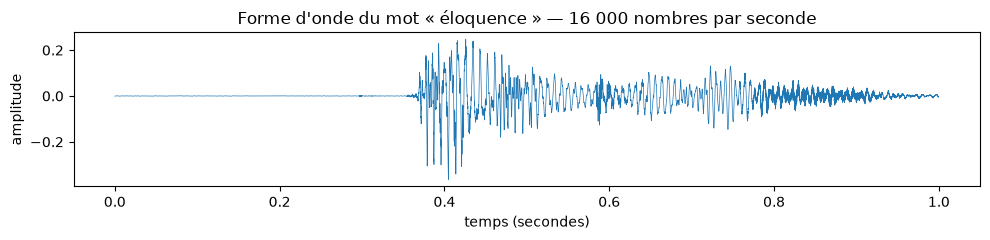

In [4]:
# La forme d'onde : ce que « voit » le micro
audio, _ = sf.read(exemple_mot, dtype="float32")
temps = np.arange(len(audio)) / SR

plt.figure(figsize=(10, 2.5))
plt.plot(temps, audio, linewidth=0.5)
plt.xlabel("temps (secondes)")
plt.ylabel("amplitude")
plt.title("Forme d'onde du mot « éloquence » — 16 000 nombres par seconde")
plt.tight_layout()
plt.show()

### Le spectrogramme log-mel : l'« image » du son

Une forme d'onde brute est difficile à apprendre. La représentation
standard découpe le son en petites tranches et mesure, pour chacune,
l'énergie dans des bandes de fréquences. Le résultat est une **image** :
le temps en abscisse, la fréquence en ordonnée.

Trois étapes, chacune motivée :

1. **STFT** (transformée de Fourier à court terme) : une tranche d'analyse
   de 16 ms toutes les 8 ms → l'énergie par fréquence, tranche par tranche ;
2. **Banc de 40 filtres mel** : regroupe les fréquences comme l'oreille
   humaine (fine en grave, grossière en aigu) ;
3. **Logarithme puis normalisation** (moyenne 0, écart-type 1 **par
   exemple**) : le réseau devient insensible au volume d'enregistrement.

Le code ci-dessous est la version pédagogique de l'implémentation unique du
dépôt (`src/coachvocal/audio/features.py`) — en production, une seule
implémentation sert l'entraînement, l'évaluation et le direct, pour
interdire toute divergence.

In [5]:
import tensorflow as tf

def log_mel(audio_1s):
    """Waveform 1 s (16 000 échantillons) -> image (124 pas de temps, 40 bandes)."""
    # 1. STFT : tranches de 255 échantillons (16 ms), une toutes les 128 (8 ms)
    stft = tf.signal.stft(audio_1s, frame_length=255, frame_step=128)
    energie = tf.abs(stft)

    # 2. 40 bandes mel entre 60 Hz et 7,6 kHz
    filtres = tf.signal.linear_to_mel_weight_matrix(
        num_mel_bins=40, num_spectrogram_bins=energie.shape[-1],
        sample_rate=SR, lower_edge_hertz=60.0, upper_edge_hertz=7600.0)
    mel = tf.tensordot(energie, filtres, axes=1)

    # 3. log + normalisation par exemple
    log = tf.math.log(mel + 1e-6)
    normalise = (log - tf.reduce_mean(log)) / (tf.math.reduce_std(log) + 1e-6)
    return normalise.numpy()

image = log_mel(audio[:SR])
print("forme de l'image :", image.shape, "= (pas de temps, bandes mel)")

forme de l'image : (124, 40) = (pas de temps, bandes mel)


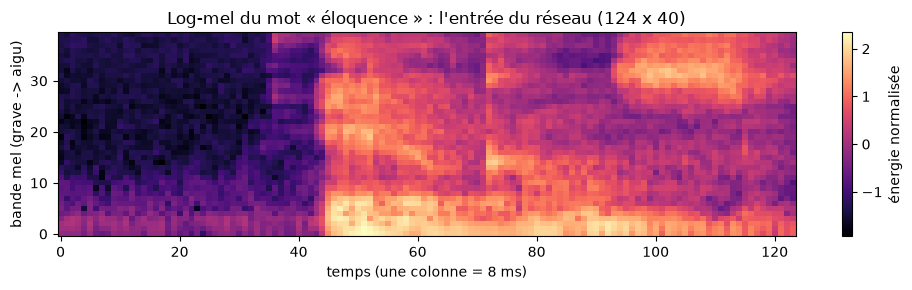

In [6]:
# L'image du mot : les traits sombres/clairs sont les harmoniques des voyelles
plt.figure(figsize=(10, 3))
plt.imshow(image.T, origin="lower", aspect="auto", cmap="magma")
plt.xlabel("temps (une colonne = 8 ms)")
plt.ylabel("bande mel (grave -> aigu)")
plt.title("Log-mel du mot « éloquence » : l'entrée du réseau (124 x 40)")
plt.colorbar(label="énergie normalisée")
plt.tight_layout()
plt.show()

### Le jeu de données

Le mot seul ne suffit pas : le détecteur doit surtout apprendre à **se
taire**. Le jeu d'entraînement mélange donc plusieurs familles de négatifs,
chacune contre un type d'erreur précis :

| Famille | Contre quelle erreur |
|---|---|
| Voix enregistrées du mot (réelles + synthèse vocale) | — (les positifs) |
| Cousins phonétiques (« éloquente », « élégance »…) | confondre un mot voisin |
| Fragments (début ou fin du mot, jamais entier) | se déclencher avant la fin |
| Parole quelconque (corpus publics français et anglais) | sonner sur de la conversation |
| Bruits, musique, silence | sonner sur l'ambiance |
| « Hard negatives » : les fausses alarmes réelles des modèles précédents | refaire les mêmes erreurs |

Deux règles d'hygiène, non négociables :

- le découpage train / validation / test est **figé une fois pour toutes**,
  par **groupe** (une même vidéo ou session ne peut pas être des deux côtés) ;
- un contrôle automatique vérifie l'absence de fuite entre les splits à
  chaque construction du jeu.

In [7]:
# La composition réelle du jeu de données du modèle CNN de référence
import csv

repartition = {}
with open(RACINE / "artifacts/runs/eloquence/v17_stack/manifest.csv", newline="") as f:
    for ligne in csv.DictReader(f):
        cle = (ligne["pool"], ligne["split"])
        repartition[cle] = repartition.get(cle, 0) + 1

pools = sorted({pool for pool, _ in repartition})
print(f"{'famille':22s} {'train':>7s} {'val':>6s} {'test':>6s}")
for pool in pools:
    train = repartition.get((pool, "train"), 0)
    val = repartition.get((pool, "val"), 0)
    test = repartition.get((pool, "test"), 0)
    print(f"{pool:22s} {train:>7d} {val:>6d} {test:>6d}")

famille                  train    val   test
cv_en                      780     98     98
cv_fr                     1560    195    195
fragments_moi              222     30     30
fragments_yt              1004    126    126
gsc                       2000    250    250
guided_positif              20      0      0
hard_neg                    54      0      0
moi_positif                 37      5      5
musan_noise               1200    150    150
proches                     36      5      4
silence                    150     20     20
speech_neg_300             300      0      0
summre_neg_75               75      0      0
tts_positif                500      0      0
yt_positif                1506    188    188


## 2. Un premier modèle : un CNN entraîné de zéro

Sur une image log-mel, la famille d'algorithmes naturelle est le **réseau
convolutif** (CNN) : les mêmes filtres appris balaient l'image et détectent
des motifs locaux (une attaque de consonne, une harmonique tenue), quelle
que soit leur position exacte — précieux car le mot n'est jamais
parfaitement centré.

Le modèle de référence du projet compte 10,2 millions de paramètres.
Pour que ce notebook s'exécute en quelques minutes, on entraîne ici une
**version réduite** du même schéma, sur un sous-ensemble des données —
la version complète, ses courbes et ses runs sont dans le dépôt.

In [8]:
from tensorflow import keras

def construire_cnn():
    """CNN réduit : le schéma du modèle de référence, en plus petit."""
    modele = keras.Sequential([
        keras.layers.Input(shape=(124, 40, 1)),

        # Bloc 1 : détecter des motifs locaux temps x fréquence
        keras.layers.Conv2D(16, kernel_size=3, padding="same", activation="relu"),
        keras.layers.MaxPooling2D(pool_size=2),

        # Bloc 2 : combiner les motifs en formes plus larges
        keras.layers.Conv2D(32, kernel_size=3, padding="same", activation="relu"),
        keras.layers.MaxPooling2D(pool_size=2),

        # Bloc 3 : motifs de haut niveau (syllabes, transitions)
        keras.layers.Conv2D(64, kernel_size=3, padding="same", activation="relu"),
        keras.layers.MaxPooling2D(pool_size=2),

        # Décision : une seule sortie sigmoïde = probabilité du mot
        keras.layers.Flatten(),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(1, activation="sigmoid"),
    ])
    return modele

cnn = construire_cnn()
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 124, 40, 16)    │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 62, 20, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 62, 20, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 31, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 31, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 5, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4800)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       307,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 330,625 (1.26 MB)

 Trainable params: 330,625 (1.26 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Charger un sous-ensemble équilibré du jeu réel (train et test)
def charger_split(nom_split, max_par_label):
    """Lit le manifest, charge les fichiers, calcule les images log-mel."""
    images = []
    labels = []
    compteur = {0: 0, 1: 0}
    with open(RACINE / "artifacts/runs/eloquence/v17_stack/manifest.csv", newline="") as f:
        for ligne in csv.DictReader(f):
            if ligne["split"] != nom_split:
                continue
            label = int(ligne["label"])
            if compteur[label] >= max_par_label:
                continue
            chemin = Path(ligne["file"])
            if not chemin.exists():
                continue
            audio, _ = sf.read(chemin, dtype="float32")
            if len(audio) < SR:
                audio = np.pad(audio, (0, SR - len(audio)))
            images.append(log_mel(audio[:SR]))
            labels.append(label)
            compteur[label] += 1
    X = np.array(images)[..., np.newaxis]
    y = np.array(labels, dtype=np.float32)
    return X, y

X_train, y_train = charger_split("train", max_par_label=400)
X_test, y_test = charger_split("test", max_par_label=200)
print("train :", X_train.shape, "— positifs :", int(y_train.sum()))
print("test  :", X_test.shape, "— positifs :", int(y_test.sum()))

train : (800, 124, 40, 1) — positifs : 400
test  : (393, 124, 40, 1) — positifs : 193


## 3. L'entraînement : optimiser une fonction de coût

Le problème est une classification binaire : la fonction de coût est
l'**entropie croisée binaire**, que l'optimiseur (Adam) minimise par
descente de gradient.

Deux précautions importantes :

- **Le déséquilibre des classes.** Dans le jeu complet, il y a 20 à 40
  négatifs pour un positif. Sans correction, prédire « jamais le mot »
  donnerait ~97 % d'exactitude — c'est pourquoi l'exactitude n'est pas un
  bon critère ici, et pourquoi chaque exemple positif reçoit un **poids**
  plus élevé dans la fonction de coût (`class_weight`).
- **L'arrêt anticipé.** L'entraînement s'arrête quand la performance de
  validation ne progresse plus, et conserve la meilleure version du modèle.

In [10]:
# Poids de classes : compenser le déséquilibre positifs/négatifs
nb_pos = float(y_train.sum())
nb_neg = float(len(y_train) - nb_pos)
poids_classes = {
    0: len(y_train) / (2.0 * nb_neg),
    1: len(y_train) / (2.0 * nb_pos),
}
print("poids du négatif :", round(poids_classes[0], 2))
print("poids du positif :", round(poids_classes[1], 2))

cnn.compile(optimizer=keras.optimizers.Adam(1e-3),
            loss="binary_crossentropy",
            metrics=["accuracy"])

historique = cnn.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=8,
    batch_size=64,
    class_weight=poids_classes,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=3, restore_best_weights=True)],
    verbose=2)

poids du négatif : 1.0
poids du positif : 1.0
Epoch 1/8


11/11 - 1s - 56ms/step - accuracy: 0.7691 - loss: 0.4381 - val_accuracy: 0.8667 - val_loss: 0.2641


Epoch 2/8


11/11 - 0s - 15ms/step - accuracy: 0.9088 - loss: 0.2578 - val_accuracy: 0.9000 - val_loss: 0.2504


Epoch 3/8


...

11/11 - 0s - 17ms/step - accuracy: 0.9750 - loss: 0.0616 - val_accuracy: 0.9333 - val_loss: 0.1763


Epoch 7/8


11/11 - 0s - 16ms/step - accuracy: 0.9824 - loss: 0.0493 - val_accuracy: 0.9000 - val_loss: 0.2441


Epoch 8/8


11/11 - 0s - 14ms/step - accuracy: 0.9912 - loss: 0.0303 - val_accuracy: 0.9083 - val_loss: 0.2785


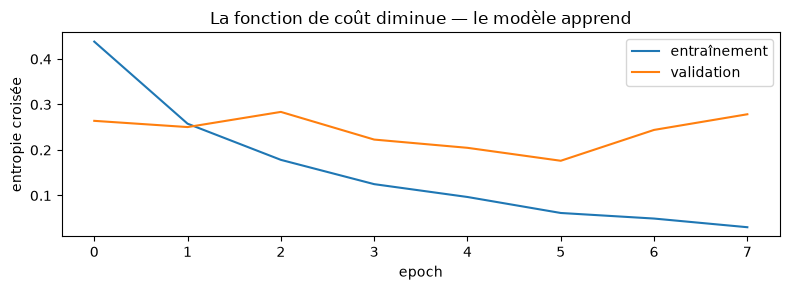

In [11]:
# Les courbes d'apprentissage : la loss d'entraînement et de validation
plt.figure(figsize=(8, 3))
plt.plot(historique.history["loss"], label="entraînement")
plt.plot(historique.history["val_loss"], label="validation")
plt.xlabel("epoch")
plt.ylabel("entropie croisée")
plt.title("La fonction de coût diminue — le modèle apprend")
plt.legend()
plt.tight_layout()
plt.show()

## 4. L'évaluation : mesurer, puis se méfier de la mesure

Les métriques du domaine, calculées sur le jeu de test (jamais vu à
l'entraînement) :

- **FRR** (*False Rejection Rate*) : le mot est prononcé, rien ne se passe ;
- **FAR** (*False Acceptance Rate*) : un négatif déclenche — l'ennemi n°1
  d'un always-on ;
- la **matrice de confusion**, la **courbe ROC** et son aire (**AUC**) ;
- le **compromis de seuil** : la sortie étant une probabilité, le seuil de
  décision se choisit — bas = sensible, haut = silencieux.

In [12]:
proba_test = cnn.predict(X_test, verbose=0).ravel()
predictions = (proba_test > 0.5).astype(int)

vrais_pos = int(np.sum((predictions == 1) & (y_test == 1)))
faux_pos  = int(np.sum((predictions == 1) & (y_test == 0)))
vrais_neg = int(np.sum((predictions == 0) & (y_test == 0)))
faux_neg  = int(np.sum((predictions == 0) & (y_test == 1)))

frr = faux_neg / max(1, faux_neg + vrais_pos)
far = faux_pos / max(1, faux_pos + vrais_neg)
print(f"FRR (mots ratés)      : {frr:.1%}")
print(f"FAR (fausses alarmes) : {far:.1%}")

FRR (mots ratés)      : 5.7%
FAR (fausses alarmes) : 8.0%


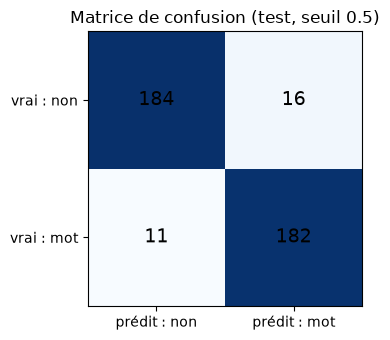

In [13]:
# Matrice de confusion
matrice = np.array([[vrais_neg, faux_pos],
                    [faux_neg, vrais_pos]])

plt.figure(figsize=(4, 3.5))
plt.imshow(matrice, cmap="Blues")
plt.xticks([0, 1], ["prédit : non", "prédit : mot"])
plt.yticks([0, 1], ["vrai : non", "vrai : mot"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, matrice[i, j], ha="center", va="center", fontsize=14)
plt.title("Matrice de confusion (test, seuil 0.5)")
plt.tight_layout()
plt.show()

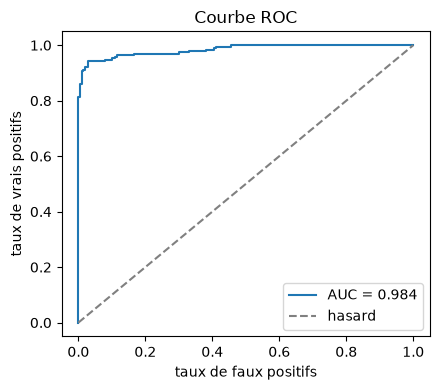

In [14]:
# Courbe ROC : le compromis sensibilité / fausses alarmes, tous seuils confondus
from sklearn.metrics import roc_curve, auc

taux_fp, taux_vp, _ = roc_curve(y_test, proba_test)
aire = auc(taux_fp, taux_vp)

plt.figure(figsize=(4.5, 4))
plt.plot(taux_fp, taux_vp, label=f"AUC = {aire:.3f}")
plt.plot([0, 1], [0, 1], "--", color="gray", label="hasard")
plt.xlabel("taux de faux positifs")
plt.ylabel("taux de vrais positifs")
plt.title("Courbe ROC")
plt.legend()
plt.tight_layout()
plt.show()

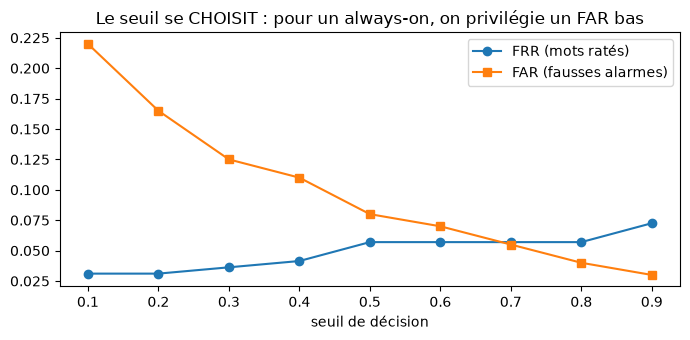

In [15]:
# Le compromis de seuil : FRR et FAR en fonction du seuil de décision
seuils = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
liste_frr = []
liste_far = []
for seuil in seuils:
    pred = (proba_test > seuil).astype(int)
    fn = np.sum((pred == 0) & (y_test == 1))
    fp = np.sum((pred == 1) & (y_test == 0))
    liste_frr.append(fn / max(1, y_test.sum()))
    liste_far.append(fp / max(1, (y_test == 0).sum()))

plt.figure(figsize=(7, 3.5))
plt.plot(seuils, liste_frr, "o-", label="FRR (mots ratés)")
plt.plot(seuils, liste_far, "s-", label="FAR (fausses alarmes)")
plt.xlabel("seuil de décision")
plt.title("Le seuil se CHOISIT : pour un always-on, on privilégie un FAR bas")
plt.legend()
plt.tight_layout()
plt.show()

### La leçon la plus importante du projet : douter de la mesure

Trois épisodes réels, documentés dans le dépôt, ont chacun invalidé une
mesure qui semblait fiable :

1. **Le test par clips a classé les modèles à l'envers.** Le modèle au
   meilleur F1 par clips s'est révélé le pire en conditions réelles. Il a
   fallu construire un **banc de simulation temps réel** : rejouer la logique
   du direct (fenêtre glissante, décision périodique, règle des fenêtres
   consécutives) sur ~53 minutes d'audio continu jamais vues à
   l'entraînement. Depuis, les décisions se prennent sur deux chiffres :
   le **rappel en flux** et les **fausses alarmes par heure**.
2. **Une conclusion a dû être rétractée.** Sur CPU, deux entraînements à
   configuration identique varient de ±0.03-0.06 de F1 : un « progrès » de
   cette taille est du bruit. D'où un protocole multi-candidats : N
   entraînements, élection par la validation, test regardé une seule fois.
3. **Le backend de calcul fabriquait un résultat.** Le plugin GPU Metal
   corrompait silencieusement gradients et probabilités (rappel en flux :
   80 % sur CPU, 0 % sur GPU — même modèle, même audio). Tout le projet
   tourne depuis sur CPU, et un test de non-régression le verrouille.

In [16]:
# Les résultats RÉELS du modèle de référence (banc temps réel, audio continu)
archive = json.loads((RACINE / "artifacts/reports/stream_bench/eloquence_20260814_024226.json").read_text())
print(f"Banc : {archive['total_seconds'] / 60:.1f} minutes d'audio continu, "
      f"{archive['n_occurrences']} occurrences réelles du mot\n")
for modele in ["v17_stack"]:
    for seuil, resultat in sorted(archive["results"][modele].items()):
        print(f"  {modele} @ seuil {seuil[2:]} : "
              f"rappel {resultat['recall_stream']:.1%} "
              f"({resultat['detected']}/{resultat['n_occ']}) · "
              f"{resultat['fa_per_hour']:.1f} fausses alarmes/heure")

Banc : 52.7 minutes d'audio continu, 27 occurrences réelles du mot

  v17_stack @ seuil 0.5 : rappel 63.0% (17/27) · 21.6 fausses alarmes/heure
  v17_stack @ seuil 0.8 : rappel 48.1% (13/27) · 6.8 fausses alarmes/heure


## 5. Le transfert d'apprentissage : l'extracteur gelé + une petite tête

Le CNN de zéro devait apprendre **deux choses à la fois** avec ~2 700
exemples du mot : ce qu'est la parole, et ce qu'est « éloquence ».

Le transfert d'apprentissage sépare les deux : un **extracteur
pré-entraîné** (publié par une équipe de recherche, entraîné sur ~200
millions de clips pour la détection de mots-clés) transforme l'audio en
**résumés de 96 nombres toutes les 80 ms** — il a déjà appris « la
parole », et on le **gèle**. Il ne reste qu'à entraîner une **tête**
minuscule (~110 000 paramètres, initialisée au hasard) qui lit les 16
derniers résumés (un tableau 16 x 96 ≈ 2 s d'audio) et répond : est-ce le
mot ?

| | CNN de zéro | Extracteur gelé + tête |
|---|---|---|
| Paramètres entraînés | 10 200 000 | 110 000 |
| Ce que les données doivent enseigner | la parole ET le mot | le mot seulement |
| Fenêtre d'audio | 1 s | ~2 s |
| Décision toutes les | 125 ms | 80 ms |

In [17]:
# L'extracteur gelé en action : de l'audio aux résumés de 96 nombres
import onnxruntime as ort

DOSSIER_ONNX = RACINE / "data/external/oww_models"
mel_onnx = ort.InferenceSession(str(DOSSIER_ONNX / "melspectrogram.onnx"),
                                providers=["CPUExecutionProvider"])
extracteur = ort.InferenceSession(str(DOSSIER_ONNX / "embedding_model.onnx"),
                                  providers=["CPUExecutionProvider"])

# 2 secondes d'audio : un souffle léger puis le mot (jamais de silence
# numérique parfait : un vrai micro n'en produit jamais)
souffle = 0.001 * np.random.default_rng(0).standard_normal(2 * SR - len(audio))
deux_secondes = np.concatenate([souffle, audio]).astype(np.float32)[np.newaxis, :]

image_mel = mel_onnx.run(None, {"input": deux_secondes})[0]
trames = np.squeeze(image_mel) / 10.0 + 2.0
print("étape 1 — image mel :", trames.shape, "(une colonne de 32 bandes / 10 ms)")

fenetres = np.stack([trames[i:i + 76] for i in range(0, len(trames) - 75, 8)])
resumes = extracteur.run(None, {"input_1": fenetres[:, :, :, np.newaxis]})[0]
resumes = resumes.reshape(len(resumes), 96)
print("étape 2 — résumés   :", resumes.shape, "(un résumé de 96 nombres / 80 ms)")

étape 1 — image mel : (197, 32) (une colonne de 32 bandes / 10 ms)
étape 2 — résumés   : (16, 96) (un résumé de 96 nombres / 80 ms)


In [18]:
# La tête : 3 petites couches denses au-dessus de l'extracteur gelé
def construire_tete():
    tete = keras.Sequential([
        keras.layers.Input(shape=(16, 96)),
        keras.layers.Flatten(),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(1, activation="sigmoid"),
    ])
    return tete

tete = construire_tete()
tete.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        98,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,753 (417.00 KB)

 Trainable params: 106,753 (417.00 KB)

 Non-trainable params: 0 (0.00 B)

### Le même problème, les mêmes précautions — et un curriculum de négatifs

La tête s'entraîne exactement comme le CNN (entropie croisée, poids de
classes, arrêt anticipé). La différence décisive s'est jouée dans les
**données** : au fil des essais mesurés, le jeu s'est enrichi de négatifs
« adversariaux » ciblant chaque faiblesse constatée :

- des **préfixes** du mot (60-85 %, fin absente) pour lui apprendre à
  attendre la fin — sinon il tirait dès « éloquen » ;
- des **suffixes** (début absent) pour exiger aussi le début — sinon
  « loquence » passait ;
- ces préfixes et suffixes **à plusieurs vitesses**, pour que la durée du
  son ne serve pas d'indice (un mot dit vite est court, comme un fragment) ;
- les **fausses alarmes réelles** des modèles précédents, réenregistrées et
  fortement pondérées.

Chaque ajout a suivi le même protocole : un critère de réussite écrit
**avant** l'entraînement, une seule variable modifiée, un verdict au banc
temps réel.

In [19]:
# Verdict final au banc temps réel : CNN de zéro contre transfert
derniere_archive = sorted((RACINE / "artifacts/reports/stream_bench").glob("eloquence_2*.json"))[-1]
banc = json.loads(derniere_archive.read_text())

print(f"Banc : {banc['total_seconds'] / 60:.1f} min d'audio continu, "
      f"{banc['n_occurrences']} occurrences\n")
for modele, par_seuil in banc["results"].items():
    for seuil, r in sorted(par_seuil.items()):
        print(f"  {modele[:38]:38s} @ {seuil[2:]:4s} : "
              f"rappel {r['recall_stream']:5.1%} · {r['fa_per_hour']:5.1f} FA/h")

Banc : 52.7 min d'audio continu, 27 occurrences

  oww_frab30np4b_s46                     @ 0.8  : rappel 81.5% ·   2.3 FA/h
  oww_frab30np4b_s46                     @ 0.9  : rappel 81.5% ·   2.3 FA/h
  oww_frab30np4b_s46                     @ 0.95 : rappel 77.8% ·   1.1 FA/h
  eloquence_v31_cousins80_64x3_seed46    @ 0.8  : rappel 88.9% ·  14.8 FA/h
  eloquence_v31_cousins80_64x3_seed46    @ 0.9  : rappel 88.9% ·  10.2 FA/h
  eloquence_v31_cousins80_64x3_seed46    @ 0.95 : rappel 88.9% ·   9.1 FA/h


## 6. Le déploiement : un registre de modèles et une API

Un modèle n'existe en production que s'il est **servi** et **tracé** :

- un **registre** désigne le champion courant (`CHAMPION.json`) : chaque
  promotion est un acte daté, justifié par des chiffres, avec l'historique
  complet des champions précédents ;
- une **API HTTP** (FastAPI) sert le champion : `/predict` (probabilité sur
  un fichier), `/detect` (la logique temps réel complète : seuil, fenêtres
  consécutives, cooldown), `/models` (le registre), documentation
  interactive générée sur `/docs` ;
- l'API sert indifféremment les **deux familles de modèles** (CNN `.keras`
  ou tête `.onnx`) : le registre résout le format, le code appelant ne
  change pas ;
- autour : suivi d'expériences (MLflow), versionnement des données (DVC),
  intégration continue (lint), 72 tests automatisés.

In [20]:
# Le registre : qui est le champion, et pourquoi (la trace de la décision)
registre = json.loads((RACINE / "artifacts/runs/eloquence/CHAMPION.json").read_text())
champion = registre["champion"]
print("Champion :", champion["run"], "— promu le", champion["promoted"])
print("Justification :", champion["reason"][:300], "…")
print("\nChampions précédents :", [h["run"] for h in registre["history"]])

Champion : oww_frab30np4b_s46 — promu le 2026-08-14
Justification : Banc 52,7 min / 27 occ (archive 20260814_211029), seuil live 0.8 : rappel 81.5 % (22/27) · 2.3 FA/h. Préfixes tronqués 80/90 % : 0 % (prédécesseur : 17/38 % — il tirait avant la fin du mot, « éloquente » passait). Cousins 0 %. Test micro validé le 2026-08-14 : « éloquence » détecté, « éloquen » et « …

Champions précédents : ['oww_frab30np_s46', 'v17_stack', 'v11_speech_300', 'v03']


In [21]:
# Appeler l'API comme un client HTTP (sans serveur externe : client de test)
from fastapi.testclient import TestClient
from coachvocal.serving.api import api

client = TestClient(api)

# 1. l'état du service
print(client.get("/health").json())

# 2. une prédiction sur un vrai fichier audio
with open(exemple_mot, "rb") as fichier:
    reponse = client.post("/predict", files={"file": (exemple_mot.name, fichier, "audio/wav")})
print(json.dumps(reponse.json(), indent=2, ensure_ascii=False))

{'status': 'ok', 'wakewords': ['eloquence'], 'experiments': ['smoke', 'v03_replica', 'v04_speech_neg', 'v05_metal_check', 'v06_metal_leaky', 'v07_metal_elu', 'v08_metal_maxrelu', 'v09_gate', 'v10_recut', 'v10b_recut_speech', 'v11_speech_100', 'v11_speech_300', 'v11_speech_500', 'v12_rir', 'v13_fa_select', 'v14_rir_speech300', 'v15_summre_neg', 'v15b_summre_150', 'v15b_summre_75', 'v16_hardneg', 'v17_stack', 'v18_guided', 'v19_fragments', 'v20_recut_anchor', 'v21_fragments_propres', 'v22_replica17', 'v23_sans_fragments', 'v24_fragments_longs']}


{
  "wakeword": "eloquence",
  "run": "oww_frab30np4b_s46",
  "probability": 0.9139341115951538,
  "detected": true,
  "threshold": 0.8,
  "peak": 0.364349365234375,
  "n_windows": 3,
  "inference_ms": 6.7
}


/Volumes/extreme_pro_ssd/alyra/13.PROJET_CERTIF/02.SOFTWARE/coach-vocal-mlops/.venv/lib/python3.11/site-packages/fastapi/testclient.py:1: StarletteDeprecationWarning: Using `httpx` with `starlette.testclient` is deprecated; install `httpx2` instead.
  from starlette.testclient import TestClient as TestClient  # noqa


En production, la même API se lance en une commande (`coachvocal serve`)
et s'appelle depuis n'importe quelle machine du réseau — la documentation
interactive sur `/docs` permet de tester chaque point d'entrée depuis un
navigateur.

## Conclusion

Partis d'un CNN entraîné de zéro (66 fausses alarmes/heure à son premier
banc), le détecteur a progressé par itérations mesurées jusqu'à un modèle
par transfert d'apprentissage qui tient les objectifs fixés (moins de 10 %
de mots ratés, moins de 5 % de fausses acceptations par clips, quelques
fausses alarmes par heure en flux continu — sur un banc volontairement
difficile).

Les trois leçons qui résument la démarche :

1. **La mesure d'abord, et la méfiance envers la mesure ensuite** — le banc
   temps réel a été construit parce que la métrique standard classait les
   modèles à l'envers ;
2. **Une variable à la fois, un critère écrit avant** — chaque amélioration
   est attribuable, chaque échec est une information ;
3. **Les données pèsent plus que l'architecture** — le passage au transfert
   a aidé, mais les gains décisifs sont venus du curriculum de négatifs
   construit sur les erreurs réellement observées.